In [1]:
import os
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt
import seaborn as sns

2025-09-04 13:22:30.265694: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1756992150.632212      19 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1756992150.725721      19 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


### Конфигурация


In [2]:
DATA_DIR = "/kaggle/input/defect/FileLudScanSaved/FileLudScanSaved"
SEQUENCE_LENGTH = 15996
WINDOW_START = 714
WINDOW_END = 885
WINDOW_LENGTH = WINDOW_END - WINDOW_START
BATCH_SIZE = 32
EPOCHS = 100
NUM_CLASSES = 14  # 7 дефектов * 2 состояния (defect/bezdefect)

### Загрузка и предобработка данных из папок

In [3]:
def load_and_preprocess_data(data_dir, num_samples=400):
    X = []
    y = []
    file_paths = []
    labels = []
    
    folders = []
    for i in range(13, 20):
        folders.extend([
            f"CO - {i} - bezdefect",
            f"CO - {i} - defect"
        ])
    
    for folder in folders:
        folder_path = os.path.join(data_dir, folder)
            
        files = os.listdir(folder_path)
        files = [f for f in files if f.endswith('.txt')]
        # только первые 400 файлов
        files = files[:num_samples]
        
        for file in files:
            file_path = os.path.join(folder_path, file)
            try:
                data = np.loadtxt(file_path)
                
                # интервал 714:885
                important_interval = data[WINDOW_START:WINDOW_END]
                
                # Нормализация сигнала
                important_interval = (important_interval - np.mean(important_interval)) / np.std(important_interval)
                
                X.append(important_interval)
                y.append(folder)
                file_paths.append(file_path)
                labels.append(folder)
                
            except Exception as e:
                print(f"Ошибка при загрузке файла {file_path}: {e}")
    
    return np.array(X), np.array(y), file_paths, labels

### Создание модели LSTM

In [4]:
def create_model(input_shape, num_classes):
    model = Sequential([
        # Первый LSTM слой
        Bidirectional(LSTM(128, return_sequences=True, input_shape=input_shape)),
        Dropout(0.3),
        
        # Второй LSTM слой
        Bidirectional(LSTM(64, return_sequences=True)),
        Dropout(0.3),
        
        # Третий LSTM слой
        Bidirectional(LSTM(32)),
        Dropout(0.3),
        
        # Полносвязные слои
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(32, activation='relu'),
        Dropout(0.2),
        
        # Выходной слой
        Dense(num_classes, activation='softmax')
    ])
    
    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy', 'precision', 'recall']
    )
    
    return model

### Визуализация процесса обучения

In [5]:
def plot_training_history(history):
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    # Accuracy
    axes[0, 0].plot(history.history['accuracy'], label='Training Accuracy')
    axes[0, 0].plot(history.history['val_accuracy'], label='Validation Accuracy')
    axes[0, 0].set_title('Model Accuracy')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Accuracy')
    axes[0, 0].legend()
    
    # Loss
    axes[0, 1].plot(history.history['loss'], label='Training Loss')
    axes[0, 1].plot(history.history['val_loss'], label='Validation Loss')
    axes[0, 1].set_title('Model Loss')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('Loss')
    axes[0, 1].legend()

    # Precision
    axes[1, 0].plot(history.history['precision'], label='Training Precision')
    axes[1, 0].plot(history.history['val_precision'], label='Validation Precision')
    axes[1, 0].set_title('Model Precision')
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('Precision')
    axes[1, 0].legend()
    
    # Recall
    axes[1, 1].plot(history.history['recall'], label='Training Recall')
    axes[1, 1].plot(history.history['val_recall'], label='Validation Recall')
    axes[1, 1].set_title('Model Recall')
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].set_ylabel('Recall')
    axes[1, 1].legend()
    
    plt.tight_layout()
    plt.show()

In [6]:
# Загрузка данных
print("Загрузка данных...")
X, y, file_paths, labels = load_and_preprocess_data(DATA_DIR)

print(f"Загружено {len(X)} сигналов")
print(f"Форма данных: {X.shape}")

# Кодирование меток
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
y_categorical = to_categorical(y_encoded)

print("Классы:", label_encoder.classes_)
print("Распределение классов:", np.bincount(y_encoded))

# Разделение на тренировочную и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(
    X, y_categorical, test_size=0.2, random_state=42, stratify=y_encoded
)

Загрузка данных...
Загружено 5600 сигналов
Форма данных: (5600, 171)
Классы: ['CO - 13 - bezdefect' 'CO - 13 - defect' 'CO - 14 - bezdefect'
 'CO - 14 - defect' 'CO - 15 - bezdefect' 'CO - 15 - defect'
 'CO - 16 - bezdefect' 'CO - 16 - defect' 'CO - 17 - bezdefect'
 'CO - 17 - defect' 'CO - 18 - bezdefect' 'CO - 18 - defect'
 'CO - 19 - bezdefect' 'CO - 19 - defect']
Распределение классов: [400 400 400 400 400 400 400 400 400 400 400 400 400 400]


In [7]:
# Изменение формы для LSTM (samples, timesteps, features)
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

print(f"Форма тренировочных данных: {X_train.shape}")
print(f"Форма тестовых данных: {X_test.shape}")

# Создание модели
model = create_model((X_train.shape[1], X_train.shape[2]), y_categorical.shape[1])

print("Архитектура модели:")
model.summary()

# Callbacks
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=5,
    min_lr=0.0001
)

Форма тренировочных данных: (4480, 171, 1)
Форма тестовых данных: (1120, 171, 1)
Архитектура модели:


I0000 00:00:1756992237.163866      19 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1756992237.164580      19 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5
/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

### Обучение модели

In [8]:
history = model.fit(
    X_train, y_train,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=(X_test, y_test),
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

Epoch 1/100


I0000 00:00:1756992248.685523      62 cuda_dnn.cc:529] Loaded cuDNN version 90300


140/140 ━━━━━━━━━━━━━━━━━━━━ 20s 49ms/step - accuracy: 0.1992 - loss: 2.3412 - precision: 0.4489 - recall: 0.0223 - val_accuracy: 0.6598 - val_loss: 1.2990 - val_precision: 0.8717 - val_recall: 0.2670 - learning_rate: 0.0010
Epoch 2/100
140/140 ━━━━━━━━━━━━━━━━━━━━ 6s 41ms/step - accuracy: 0.5384 - loss: 1.3650 - precision: 0.7806 - recall: 0.3092 - val_accuracy: 0.8098 - val_loss: 0.6353 - val_precision: 0.8910 - val_recall: 0.7446 - learning_rate: 0.0010
Epoch 3/100
140/140 ━━━━━━━━━━━━━━━━━━━━ 6s 41ms/step - accuracy: 0.7170 - loss: 0.8877 - precision: 0.8428 - recall: 0.6184 - val_accuracy: 0.8616 - val_loss: 0.4403 - val_precision: 0.9235 - val_recall: 0.8411 - learning_rate: 0.0010
Epoch 4/100
140/140 ━━━━━━━━━━━━━━━━━━━━ 6s 41ms/step - accuracy: 0.7722 - loss: 0.7171 - precision: 0.8765 - recall: 0.6917 - val_accuracy: 0.8902 - val_loss: 0.3816 - val_precision: 0.9517 - val_recall: 0.8795 - learning_rate: 0.0010
Epoch 5/100
140/140 ━━━━━━━━━━━━━━━━━━━━ 6s 41ms/step - accuracy: 0

Оценка модели на тестовых данных...
Test Accuracy: 0.9554
Test Precision: 0.9849
Test Recall: 0.9339
Test Loss: 0.1469


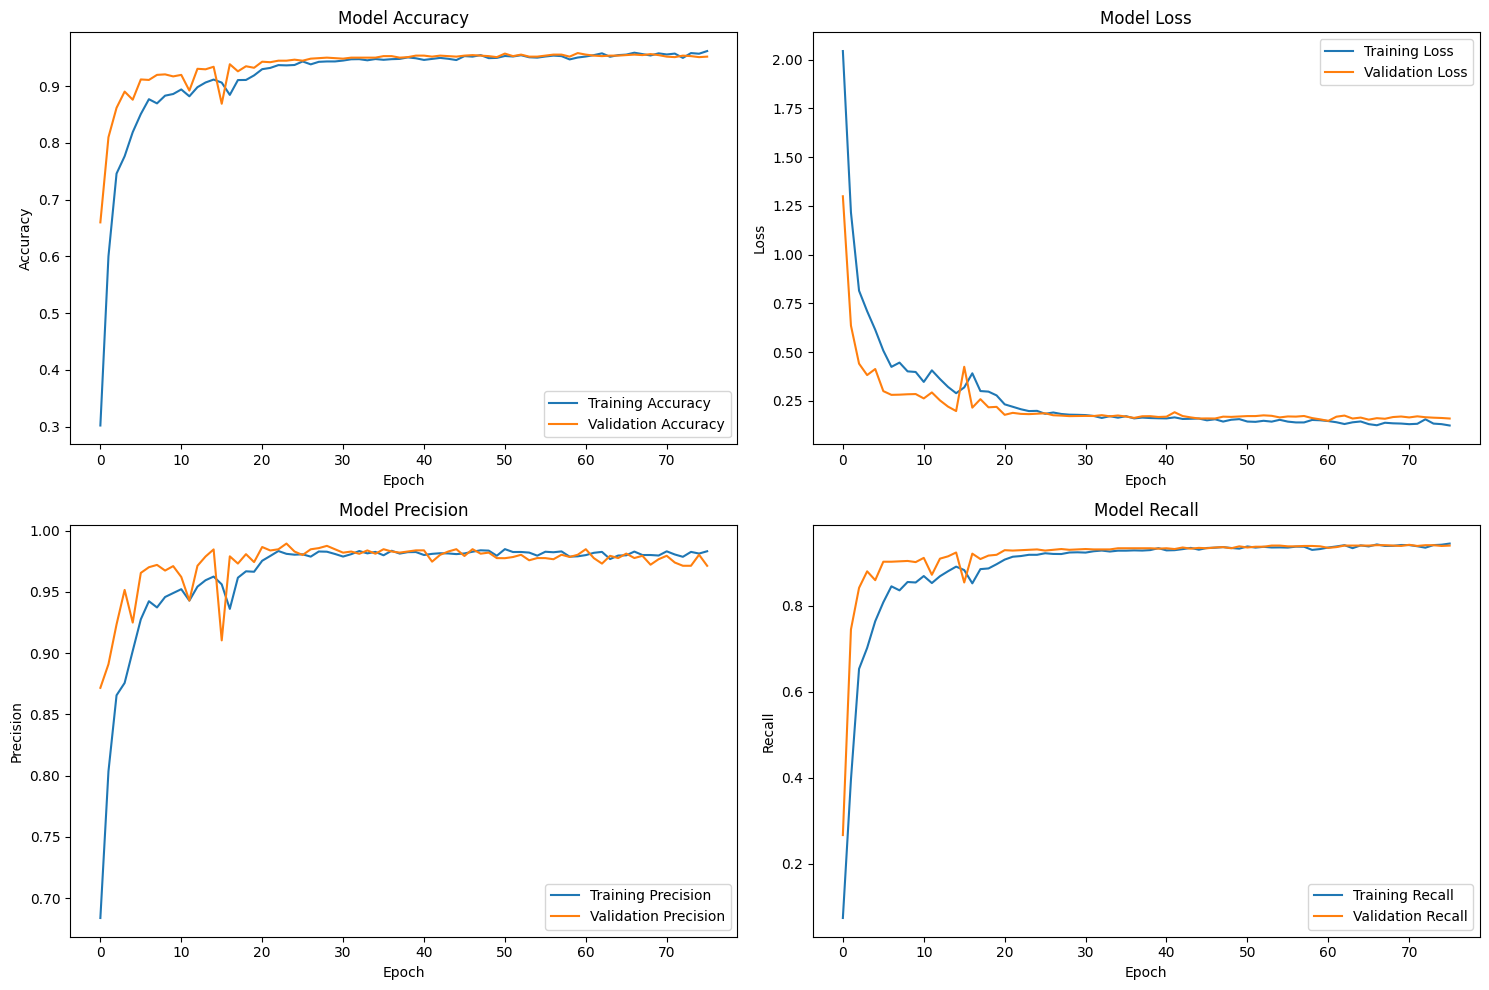

In [9]:
# Оценка модели
print("Оценка модели на тестовых данных...")
test_loss, test_accuracy, test_precision, test_recall = model.evaluate(X_test, y_test, verbose=0)

print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Precision: {test_precision:.4f}")
print(f"Test Recall: {test_recall:.4f}")
print(f"Test Loss: {test_loss:.4f}")

# Визуализация обучения
plot_training_history(history)

35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step

Classification Report:
                     precision    recall  f1-score   support

CO - 13 - bezdefect       0.92      0.96      0.94        80
   CO - 13 - defect       0.95      0.90      0.92        80
CO - 14 - bezdefect       0.97      0.94      0.96        80
   CO - 14 - defect       1.00      0.99      0.99        80
CO - 15 - bezdefect       0.94      0.99      0.96        80
   CO - 15 - defect       0.90      0.95      0.93        80
CO - 16 - bezdefect       0.99      0.95      0.97        80
   CO - 16 - defect       0.99      0.96      0.97        80
CO - 17 - bezdefect       0.94      0.99      0.96        80
   CO - 17 - defect       0.99      0.96      0.97        80
CO - 18 - bezdefect       0.89      0.97      0.93        80
   CO - 18 - defect       0.95      0.97      0.96        80
CO - 19 - bezdefect       0.97      0.94      0.96        80
   CO - 19 - defect       1.00      0.90      0.95        80

           accuracy

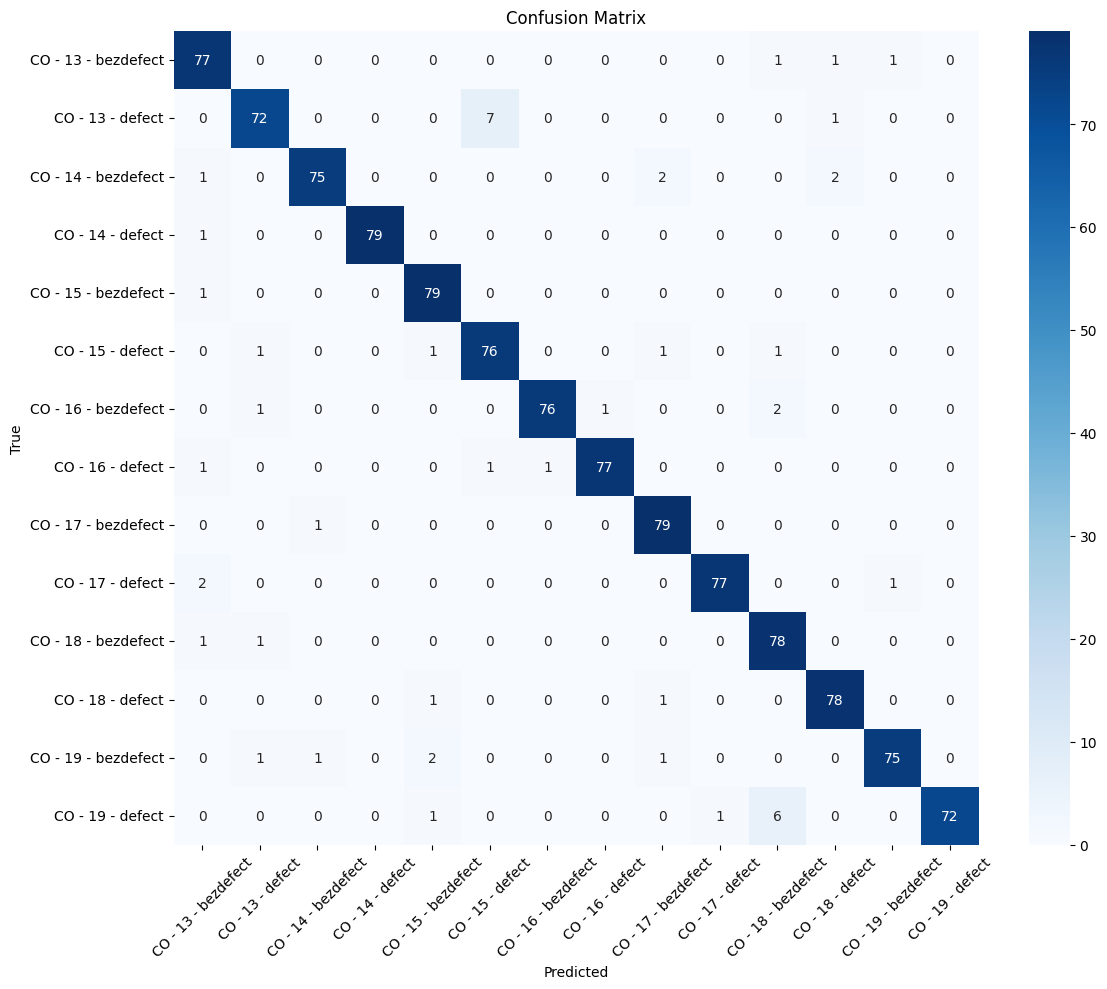

In [10]:
# Предсказания
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

# Отчет классификации
print("\nClassification Report:")
print(classification_report(
    y_true_classes, 
    y_pred_classes, 
    target_names=label_encoder.classes_
))

# Матрица ошибок
plt.figure(figsize=(12, 10))
cm = confusion_matrix(y_true_classes, y_pred_classes)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()



In [11]:
# Сохранение модели
model.save('defect_classification_model.h5')
print("Модель сохранена как 'defect_classification_model.h5'")

# Сохранение label encoder
np.save('label_encoder_classes.npy', label_encoder.classes_)
print("Label encoder сохранен")

Модель сохранена как 'defect_classification_model.h5'
Label encoder сохранен


### Предсказание для нового сигнала

In [12]:
def predict_new_signal(model_path, signal_path, label_encoder_path):
    # Загрузка модели и label encoder
    model = tf.keras.models.load_model(model_path)
    label_encoder_classes = np.load(label_encoder_path, allow_pickle=True)
    label_encoder = LabelEncoder()
    label_encoder.classes_ = label_encoder_classes
    
    # Загрузка и предобработка сигнала
    data = np.loadtxt(signal_path)
    # important_interval = data[WINDOW_START:WINDOW_END]

    
    important_interval = data[0:171]
    important_interval = (important_interval - np.mean(important_interval)) / np.std(important_interval)

    # при умножении сигнала ошибается:
    # important_interval = important_interval * 3
    
    # Подготовка для предсказания
    X_new = important_interval.reshape(1, WINDOW_LENGTH, 1)
    
    # Предсказание
    prediction = model.predict(X_new)
    predicted_class = np.argmax(prediction, axis=1)
    predicted_label = label_encoder.inverse_transform(predicted_class)
    confidence = np.max(prediction)
    
    print(f"Предсказанный класс: {predicted_label[0]}")
    print(f"Уверенность: {confidence:.4f}")
    
    return predicted_label[0], confidence

### Тесты

In [13]:
predict_new_signal('/kaggle/input/defect/defect_classification_model.h5', 
                   '/kaggle/input/defect/test/test/19d/scan_410.txt', 
                   '/kaggle/input/defect/label_encoder_classes.npy')

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 679ms/step
Предсказанный класс: CO - 18 - defect
Уверенность: 0.4630


('CO - 18 - defect', 0.46300536)